In [11]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.9.2
QuTiP version: 5.2.2


## Define experimental parameters

In [12]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.01,  
    dephasing = 0.01,      
    relaxation = 0.01
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.01]
  Dephasing rate:       [0.01]
  Relaxation rate:      [0.01]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


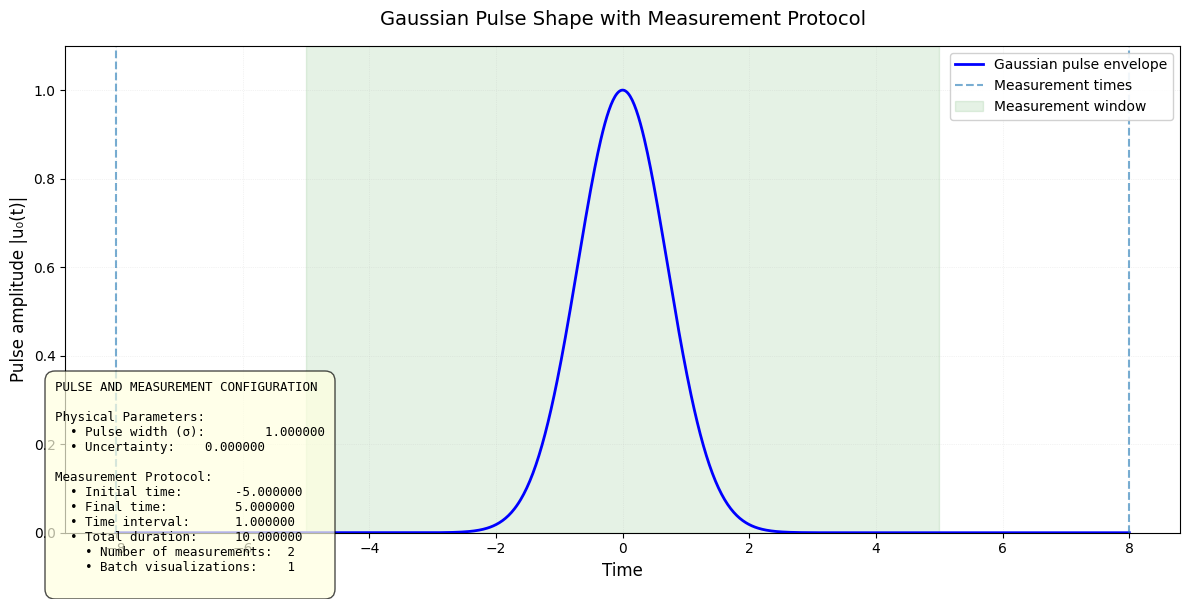

In [13]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [14]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.571)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [15]:
detection_metric = DetectionMetric(n_qubits=1, 
                                   detection_criterion = 'max computational distance',
                                   detection_param=(4,2))

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



E0504 23:10:57.231561  477068 cuda_blas.cc:196] failed to create cublas handle: the resource allocation failed
E0504 23:10:57.231579  477068 cuda_blas.cc:199] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with support for the GPU in your machine.
E0504 23:10:57.231619  477068 autotuner.cc:197] Failed to autotune HLO: %custom-call.1 = (c128[8,8]{1,0}, s8[2048]{0}) custom-call(%left_0_.1, %right_0_.1), custom_call_target="__cublas$gemm", metadata={op_name="jit(matmul_jaxarray)/dot_general" stack_frame_id=10}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"gemm_backend_config":{"alpha_real":1,"beta":0,"dot_dimension_numbers":{"lhs_contracting_dimensions":["1"],"rhs_contracting_dimensions":["0"],"lhs_batch_dimensions":[],"rhs_batch_dimensions":[]},"alpha_imag":0,"precision_config":{"ope

JaxRuntimeError: INTERNAL: Autotuner could not find any supported configs for HLO: %custom-call.1 = (c128[8,8]{1,0}, s8[2048]{0}) custom-call(%left_0_.1, %right_0_.1), custom_call_target="__cublas$gemm", metadata={op_name="jit(matmul_jaxarray)/dot_general" stack_frame_id=10}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"gemm_backend_config":{"alpha_real":1,"beta":0,"dot_dimension_numbers":{"lhs_contracting_dimensions":["1"],"rhs_contracting_dimensions":["0"],"lhs_batch_dimensions":[],"rhs_batch_dimensions":[]},"alpha_imag":0,"precision_config":{"operand_precision":["DEFAULT","DEFAULT"],"algorithm":"ALG_UNSET"},"epilogue":"DEFAULT","lhs_stride":"64","rhs_stride":"64","grad_x":false,"grad_y":false,"damax_output":false,"autotune_workspace_size":"0"},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}

## Test Single Simulation

In [ ]:
results = experiment.run_simulation(debug=False, states_probabilities=True)
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.071382
     Metric:            -0.071382
  State Probabilities:
     With photon:
        0: 0.029801
        1: 0.970199
     Without photon:
        0: 0.970255
        1: 0.029745
  Detection States:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Detection Metrics:
     --------------------
     True Positive:  0.970199
     False Negative: 0.029801
     --------------------
     True Negative:  0.970255
     False Positive: 0.029745
     --------------------


## Time Evolution

In [ ]:
'''result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()'''

"result = experiment.time_evolution(n_points=300, with_interaction=True)\nprint(result)\n\nfrom qsopt.utils.visualization import plot_time_evolution\nplot_time_evolution(\n    evolution_data=result,\n    show_pulse=True,\n    show_measurements=True,\n    show_cavity_population=True,  # Cavity population (purple)\n    show_field_population=True,   # External field population (brown)\n    title='Single Qubit Evolution',\n    figsize=(10, 6)\n)\nplt.show()"

## Run Optimization

In [ ]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[1, -0.8], 
    num_steps=100,
    verbose=True,
    verbose_step=5,
    batch_size=1,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.000  rad (57.3°)
        param1.  reset_RY[0]  = -0.800 rad (-45.8°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------
0     1.000000       -0.800000      -0.469071   6.47e-01    00h00m05s
1     1.218508       -1.038776      -0.270040   5.58e-01    00h00m06s
2     1.385479       -1.262511      -0.139061   3.63e-01    00h00m06s
5     1.551961       -1.537311      -0.072179   4.15e-02    00h00m06s
10    1.570409       -1.570109      -0.071382   8.53e-04    00h00m07s
15    1.570788       -1.570783      -0.071382   1.75e-05    00h00m08s
20    1.570796       -1.570797      -0.071382   3.61e-07    00h00m09s
22    

In [ ]:
print(history)

MODE: Optimization
     Total iterations: 23
     Best epoch:        23
     Converged: True
     Final gradient norm: 7.628231e-08
  Best Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570797 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.071382
     Metric:            -0.071382
  State Probabilities:
     With photon:
        0: 0.029801
        1: 0.970199
     Without photon:
        0: 0.970255
        1: 0.029745
  Detection States:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Detection Metrics:
     --------------------
     True Positive:  0.970199
     False Negative: 0.029801
     --------------------
     True Negative:  0.970255
     False Positive: 0.029745
     --------------------


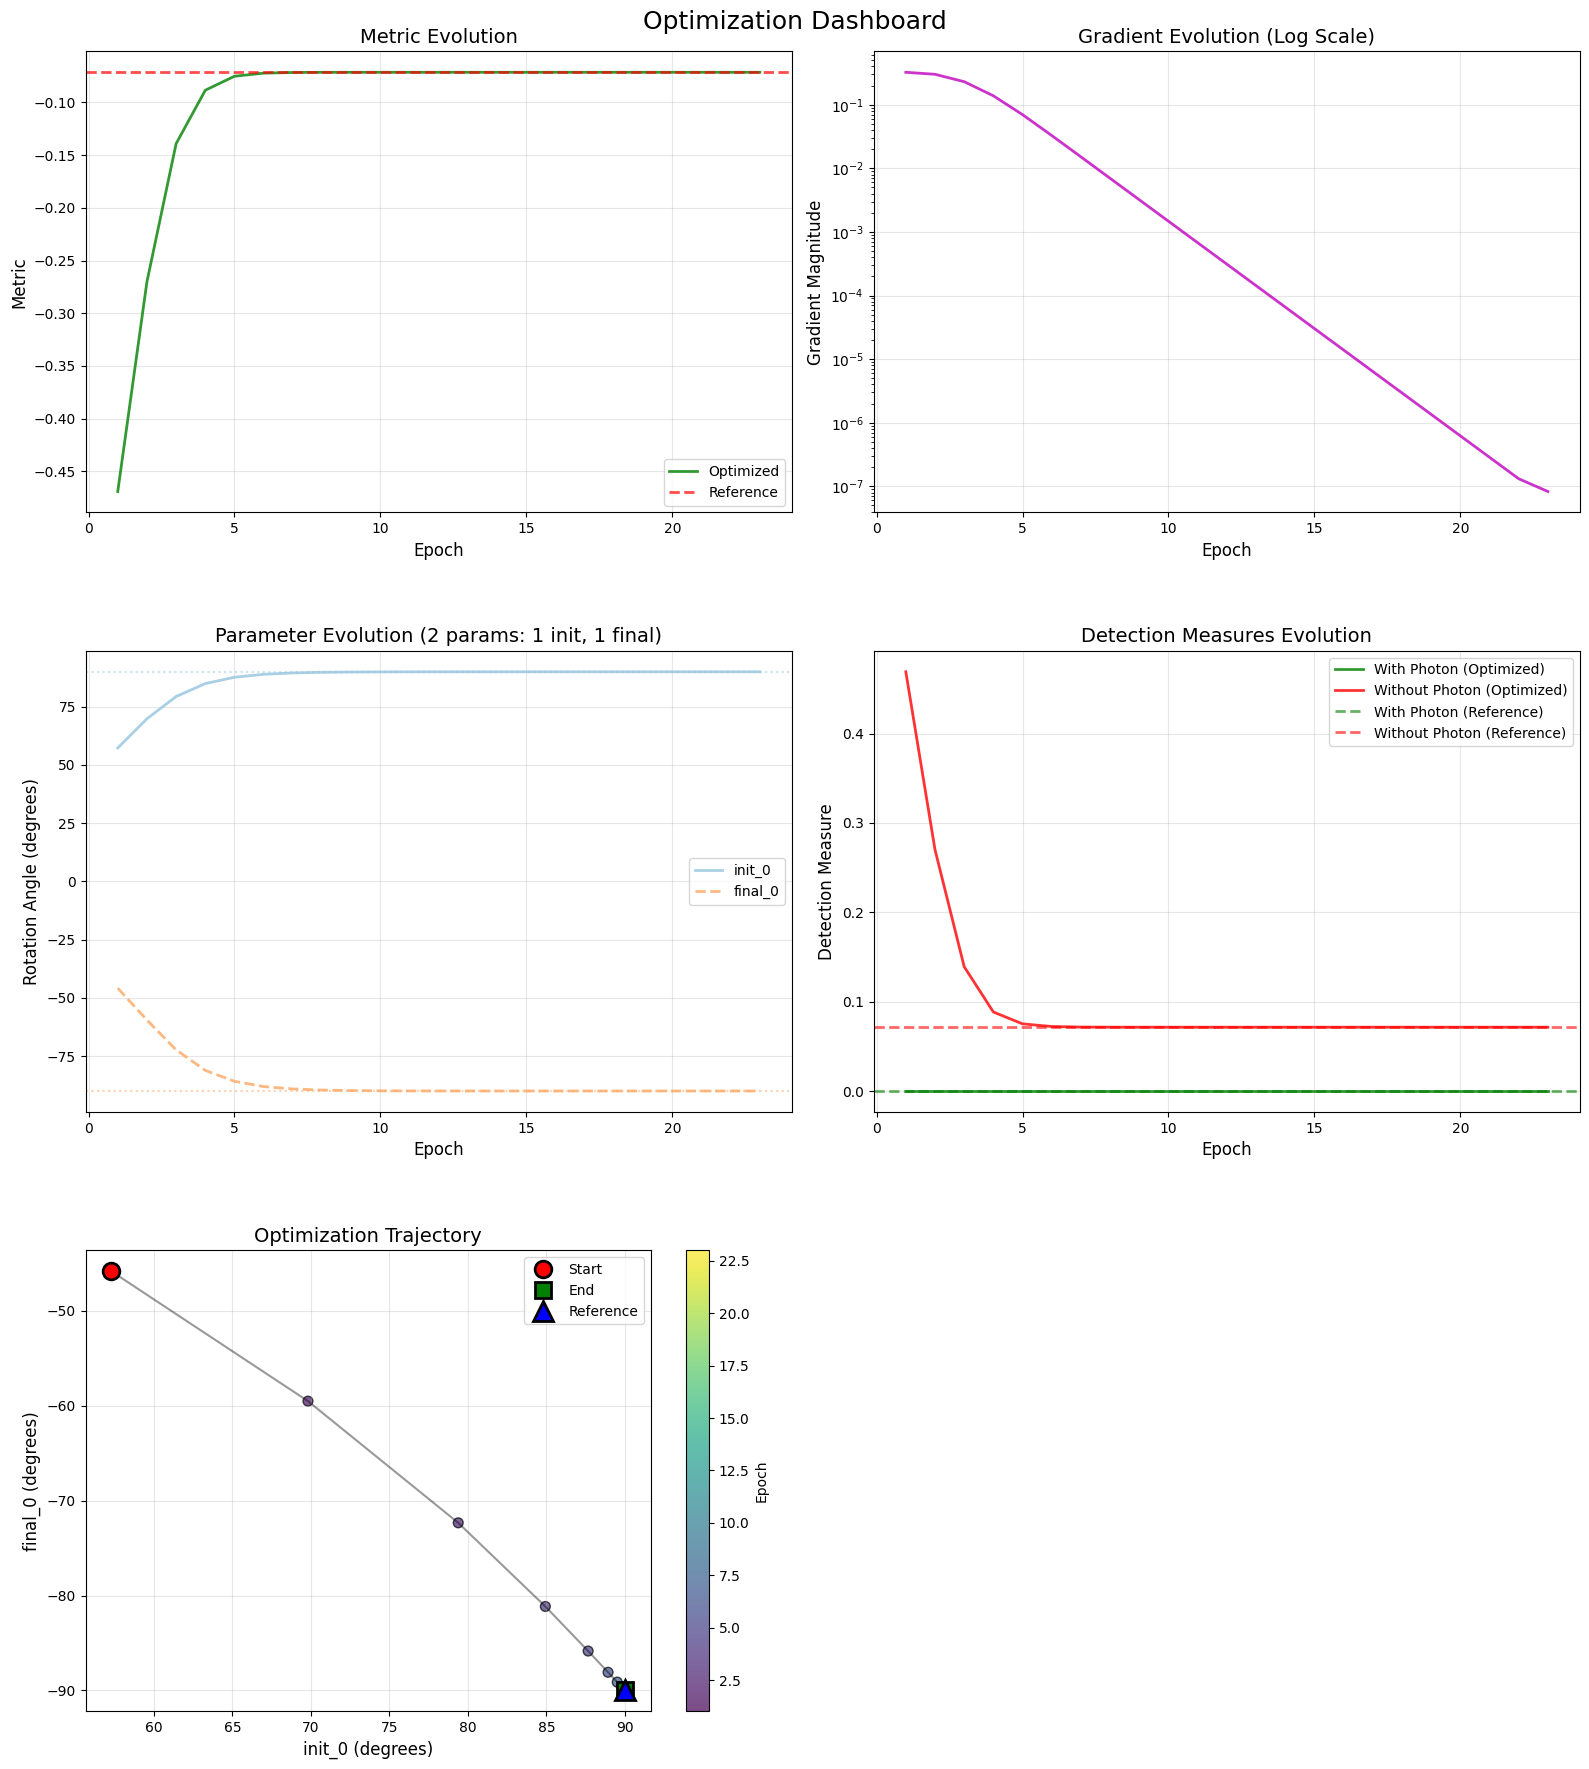

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [ ]:
# time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

In [ ]:
# from qsopt.utils.visualization import plot_time_interval_landscape

# fig = plot_time_interval_landscape(
#     landscape_data=time_callback,
#     exp_params=experiment.experimental_params,
#     save_path='results/time_interval_opt.pdf'
# )


## Sweep chi-gamma

In [ ]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)


  Progress: 10.0% | Elapsed: 24.2s


SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: detection_map, detection_without_map, metric_map
  Optimal point: chi=30, gamma=60


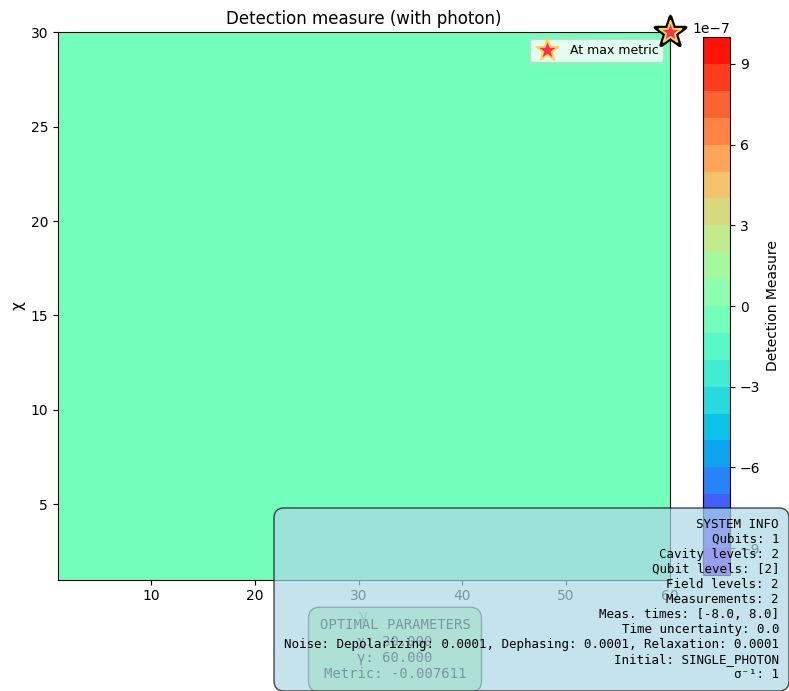

In [ ]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Continue Optimization From a Saved Callback

You can stop and resume optimization by saving the callback to disk and loading it back with `OptimizationCallback.load_callback`.
This restores both parameters and optimizer state (and gradients), so `hot_start=True` continues from the saved point.

In [ ]:
history.save('results/single_qubit_hotstart.npz')

loaded_history = OptimizationCallback.load_callback('results/single_qubit_hotstart.npz')

history_resumed = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    verbose=True,
    verbose_step=1,
    tolerance=1e-7,
    callback=loaded_history,
    optimizer=optax.sgd(learning_rate=0.5),
    hot_start=True,
)

print(history_resumed)

print('\n' + '-' * 80 + '\n')

# Build a fresh experiment for a clean 15-step baseline from the same initial values
baseline_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=create_ry_circuit(n_qubits=1, theta_values=[np.pi / 2]),
    final_circuit=create_ry_circuit(n_qubits=1, theta_values=[-np.pi / 2]),
    detection_metric=detection_metric,
 )

continued_callback = OptimizationCallback(save_every=1, save_best=True)
history_continued = baseline_experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=15,
    verbose=True,
    verbose_step=1,
    batch_size=1,
    tolerance=1e-7,
    callback=continued_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

print(history_continued)

m_resumed = np.array(history_resumed.history['metric'], dtype=float)
m_continued = np.array(history_continued.history['metric'], dtype=float)
n_overlap = min(len(m_resumed), len(m_continued))
print(f'len(resumed)={len(m_resumed)}, len(continued)={len(m_continued)}')
print('max_abs_metric_diff_on_overlap=', float(np.max(np.abs(m_resumed[:n_overlap] - m_continued[:n_overlap]))))

Starting hot start optimization, trying to load last parameters, optimizer state, and gradients from callback:
- Parameters LOADED
- Gradients LOADED
- Optimizer state LOADED
Resuming from epoch 19, running until epoch 29
Configuration:
    Max iterations: 29
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.571  rad (90.0°)
        param1.  reset_RY[0]  = -1.571 rad (-90.0°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------


19    1.570796       -1.570796      -0.007683   3.63e-08    00h00m06s
Final gradient norm: 3.63e-08
Best metric: -0.007683
Best parameters:
    param0. setup_RY[0](param=1.571)=1.571 rad (90.0°)
    param1. reset_RY[0](param=-1.571)=-1.571 rad (-90.0°)
MODE: Optimization
     Total iterations: 20
     Best epoch:        20
     Converged: True
     Final gradient norm: 3.631178e-08
  Best Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.007683
     Metric:            -0.007683
  State Probabilities:
     With photon:
        0: 0.003116
        1: 0.996884
     Without photon:
        0: 0.996943
        1: 0.003057
  Detection States:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Detection Metrics:
     --------------------
     True Positive:  0.996884
     False Negative: 0.003116
     ------------------

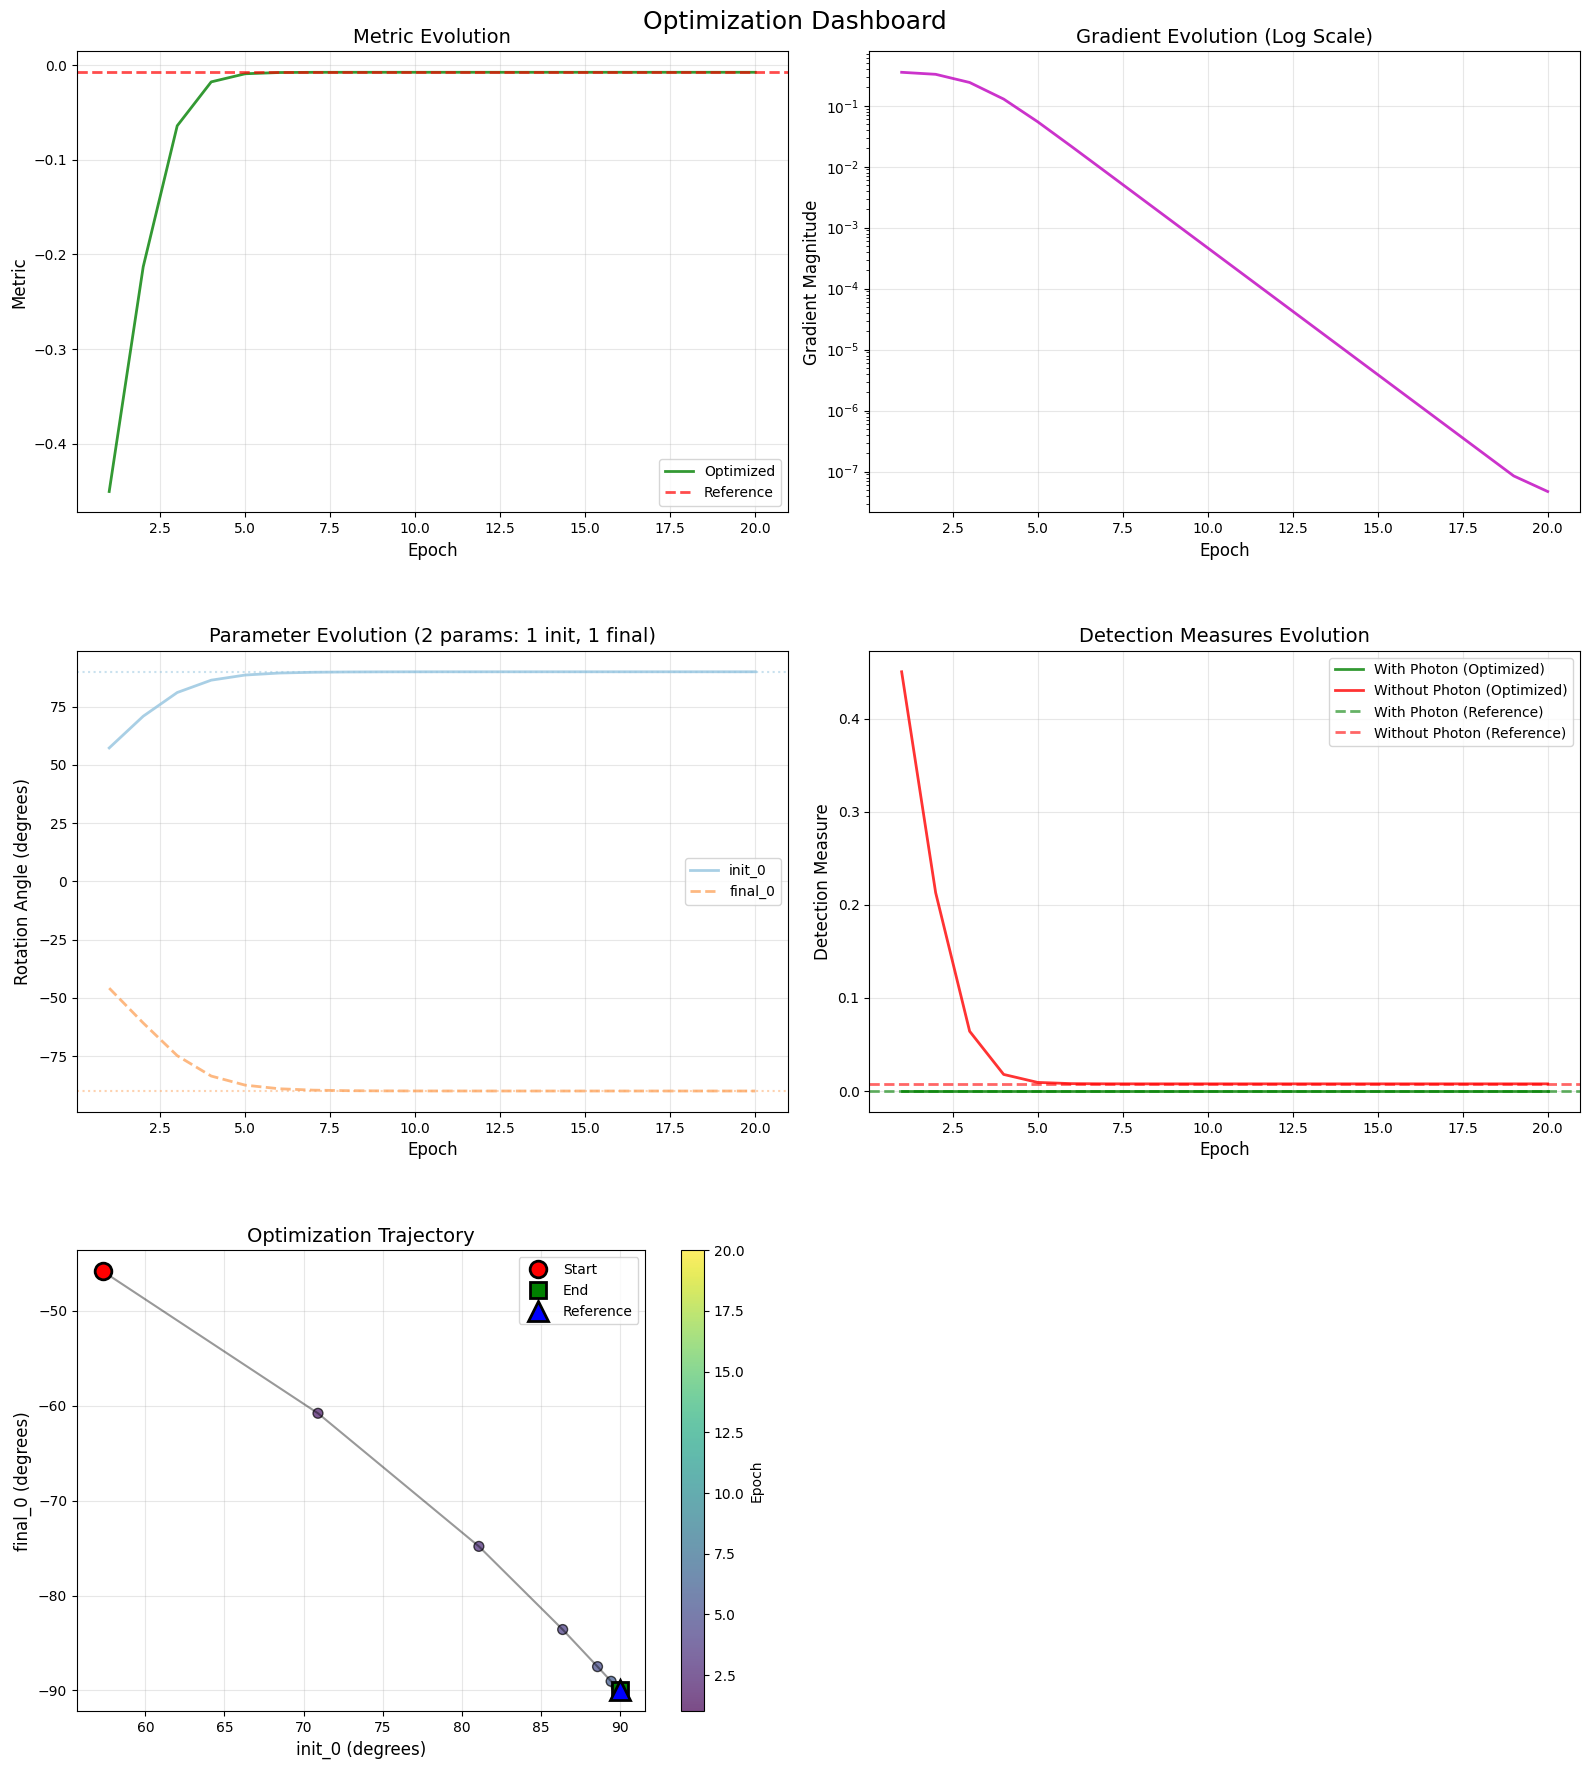

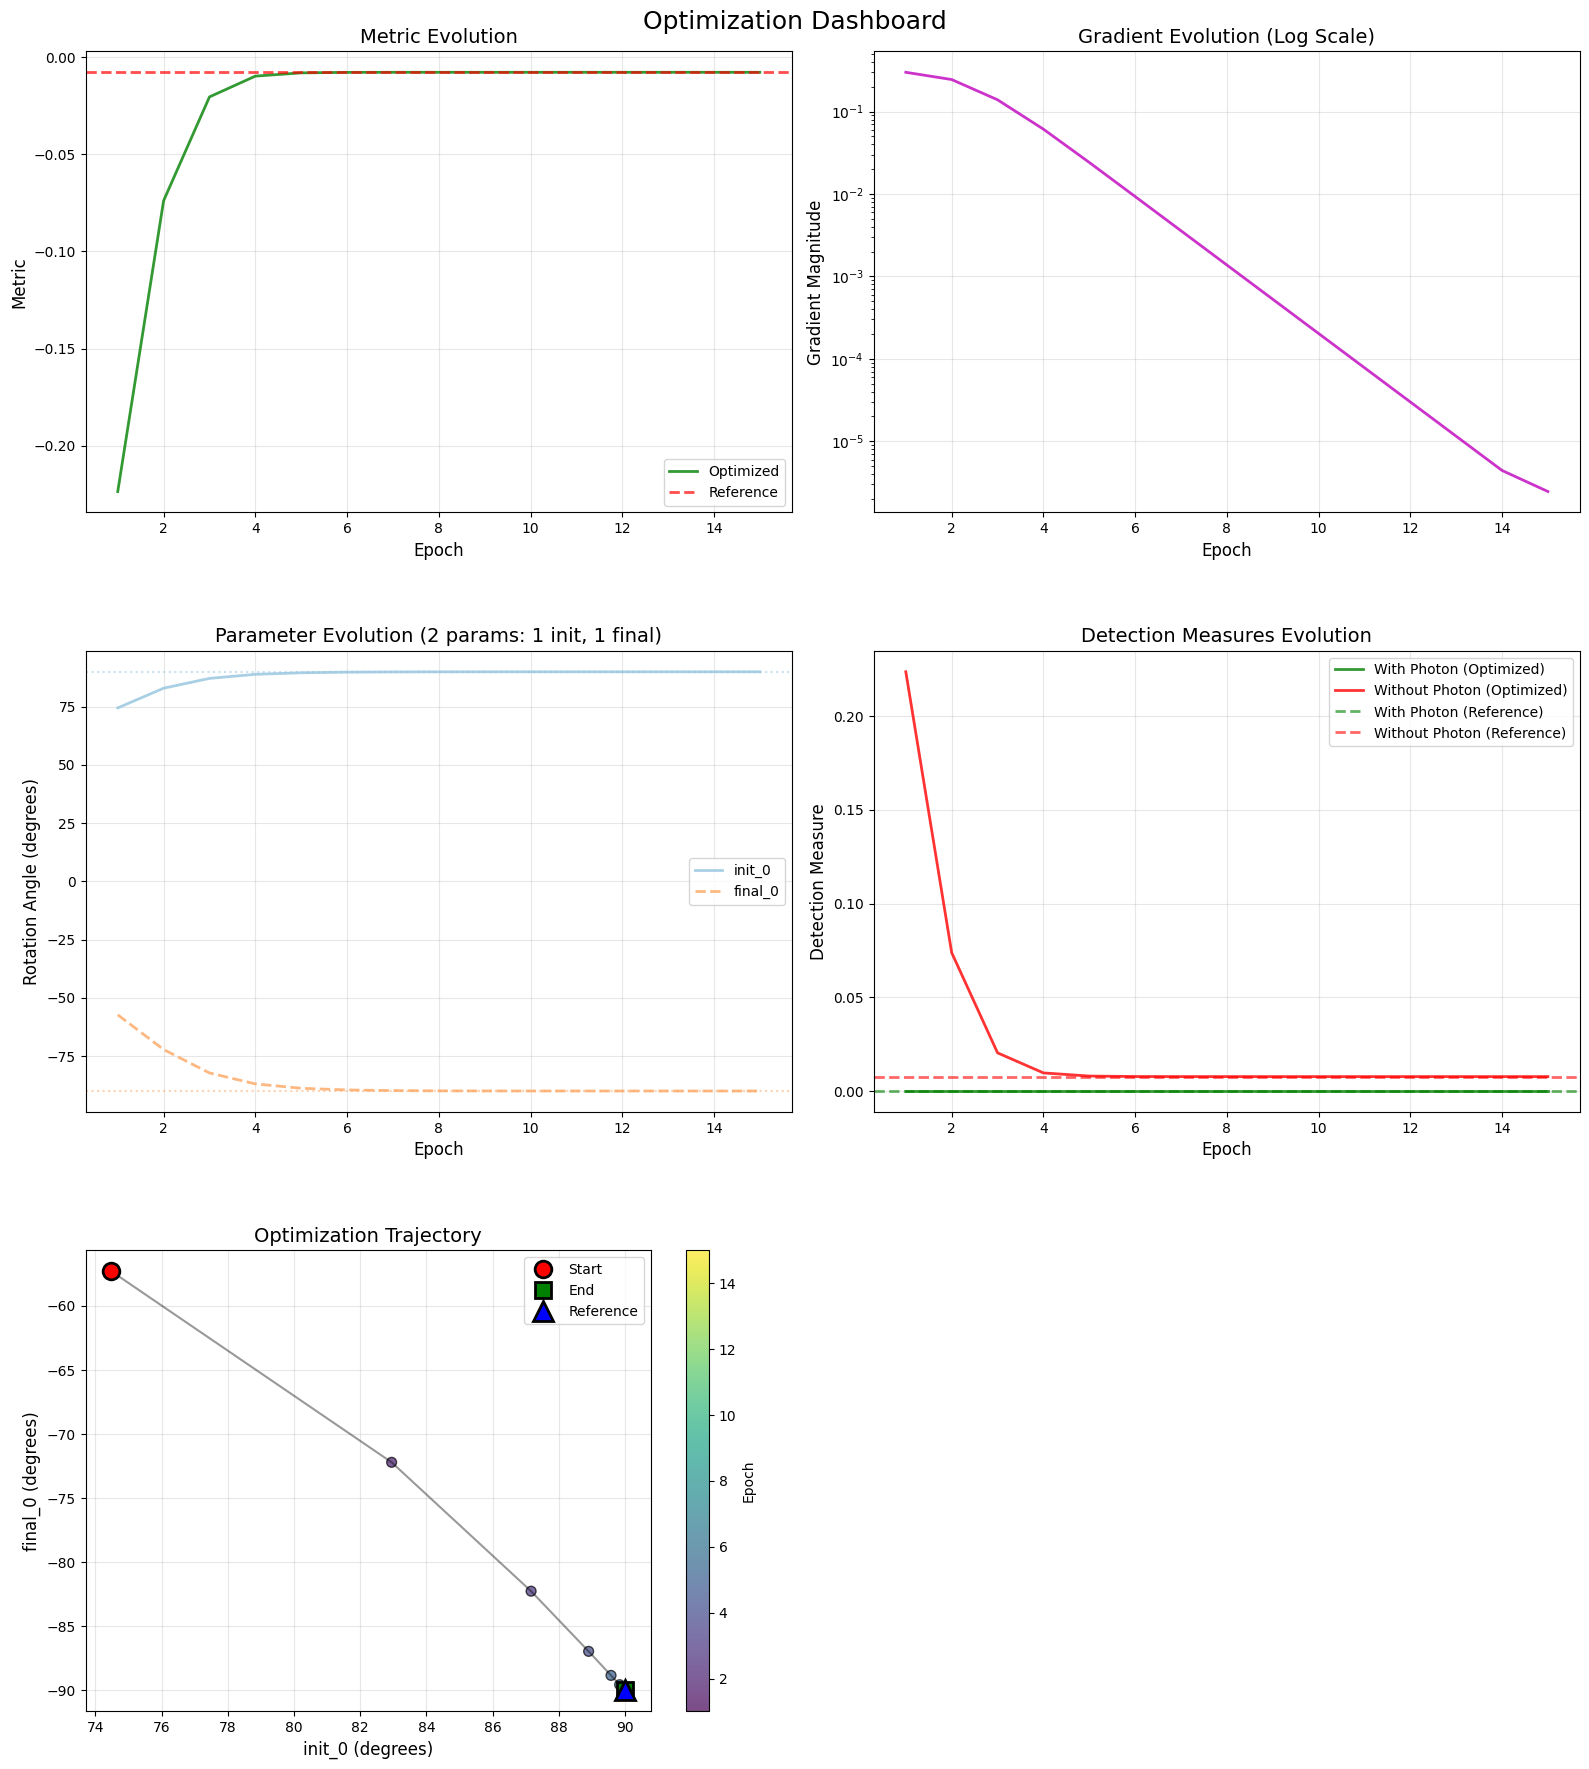

In [ ]:
# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_resumed,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_continued,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

In [ ]:
import numpy as np

res_epochs = np.array(history_resumed.history.get('epochs', []), dtype=int)
res_metric = np.array(history_resumed.history.get('metric', []), dtype=float)

cont_epochs = np.array(history_continued.history.get('epochs', []), dtype=int)
cont_metric = np.array(history_continued.history.get('metric', []), dtype=float)

print('resumed_epochs:', res_epochs.tolist())
print('resumed_metric:', res_metric.tolist())
print('continued_epochs:', cont_epochs.tolist())
print('continued_metric:', cont_metric.tolist())

n = min(len(res_metric), len(cont_metric))
print('overlap_len:', n)
if n > 0:
    diffs = np.abs(res_metric[:n] - cont_metric[:n])
    print('overlap_abs_diff:', diffs.tolist())
    print('max_abs_diff_overlap:', float(np.max(diffs)))

print('history_epochs:', history.history.get('epochs', []))
print('history_metric:', history.history.get('metric', []))

resumed_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
resumed_metric: [-0.4503294901670084, -0.21306953058248104, -0.06417149103335117, -0.017803321947490833, -0.009231763223591517, -0.007913200490598574, -0.00771738503681447, -0.007688459738169335, -0.007684190138074126, -0.007683559967947026, -0.007683466958709377, -0.007683453231086283, -0.007683451204966197, -0.007683450905922024, -0.00768345086178432, -0.007683450855269731, -0.007683450854308021, -0.007683450854166437, -0.007683450854145052, -0.007683450854143086]
continued_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
continued_metric: [-0.2236668473677213, -0.07381805103312762, -0.020357406703111376, -0.009655750464998267, -0.00797694956032373, -0.007726821119241758, -0.007689853235109834, -0.007684395858134671, -0.007683590336763518, -0.007683471441793955, -0.007683453892885862, -0.007683451302660997, -0.0076834509203440714, -0.007683450863913257, -0.00768345085558418]
overlap_len